<a href="https://colab.research.google.com/github/braswellcolin/mane4961/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q4

In [2]:
from sklearn import datasets

iris = datasets.load_iris()

iris.feature_names

iris.target_names

X = iris.data[:, :3] # only selecting first three features
y = iris.target

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.40,
    train_size=0.60,
    random_state=123,
    shuffle=True,
    stratify=y)

from sklearn import svm

clf = svm.SVC()
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
print('iris species predictions')
print(preds)

print('\nactual iris species')
print(y_test)

from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,clf.predict(X_test) )
print('\naccuracy score :', acc)

iris species predictions
[1 1 1 1 0 2 2 0 0 2 0 2 2 1 2 0 1 2 0 2 2 0 2 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 2 0 0 1 1 2 1 2 1 1 2 1 1]

actual iris species
[1 1 1 1 0 1 2 0 0 2 0 2 2 1 2 0 1 2 0 2 2 0 1 0 0 2 1 0 0 0 0 0 1 2 0 1 1
 2 0 1 0 2 2 2 0 2 2 1 0 0 1 1 2 1 2 1 1 2 1 2]

accuracy score : 0.9333333333333333


Q5

In [9]:
import tensorflow as tf
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers


#X = np.array([
#    [1.0], [128.0], [2187.0], [16384.0], [78125.0],
#    [279936.0], [823543.0], [2097152.0], [4782969.0], [10000000.0]
#])

#y = np.array([
#    [1.0], [2.0], [3.0], [4.0], [5.0],
#    [6.0], [7.0], [8.0], [9.0], [10.0]
#])

X = np.array([
    [1.0], [128.0], [2187.0], [16384.0], [78125.0],
    [279936.0], [823543.0], [2097152.0], [4782969.0], [10000000.0],
    [19487171.0], [35831808.0], [62748517.0], [105413504.0],
    [170859375.0], [268435456.0], [410338673.0], [612220032.0],
    [893871739.0], [1280000000.0]
])

y = np.array([
    [1.0], [2.0], [3.0], [4.0], [5.0],
    [6.0], [7.0], [8.0], [9.0], [10.0],
    [11.0], [12.0], [13.0], [14.0], [15.0],
    [16.0], [17.0], [18.0], [19.0], [20.0]
])

model = Sequential()
model.add(Dense(6, input_dim=1, activation="relu"))
model.add(Dense(6, activation="relu"))
model.add(Dense(6, activation="relu"))
model.add(Dense(1))

opt = optimizers.Adam(learning_rate=0.001)
mse = tf.keras.losses.MeanSquaredError(
    reduction=tf.keras.losses.Reduction.SUM
)
model.compile(loss=mse, optimizer=opt)
model.fit(X, y, epochs=2000, batch_size=10, verbose=0)

predictions = model.predict(X, verbose=0)

for i in range(len(X)):
    print(f"Predicted: {predictions[i][0]:.2f}, Expected: {y[i][0]:.2f}")

percent_errors = np.abs(predictions - y) / y * 100
print(f"\nAverage percent error: {np.mean(percent_errors):.2f}%")

Predicted: 0.14, Expected: 1.00
Predicted: 0.18, Expected: 2.00
Predicted: 0.18, Expected: 3.00
Predicted: 0.18, Expected: 4.00
Predicted: 0.18, Expected: 5.00
Predicted: 0.20, Expected: 6.00
Predicted: 0.21, Expected: 7.00
Predicted: 0.20, Expected: 8.00
Predicted: 0.41, Expected: 9.00
Predicted: -0.22, Expected: 10.00
Predicted: 2.22, Expected: 11.00
Predicted: 2.53, Expected: 12.00
Predicted: 1.78, Expected: 13.00
Predicted: 8.03, Expected: 14.00
Predicted: 7.53, Expected: 15.00
Predicted: 14.03, Expected: 16.00
Predicted: 20.03, Expected: 17.00
Predicted: 46.03, Expected: 18.00
Predicted: 80.03, Expected: 19.00
Predicted: -35.97, Expected: 20.00

Average percent error: 103.77%


Q6

In [13]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras import optimizers
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split


# Load Iris data
iris = datasets.load_iris()

# Input is sepal length; output is petal length
X = iris.data[:, [0]]
Y = iris.data[:, [2]]

#print(X)
#print(Y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.40, train_size=0.60, random_state=123, shuffle=True
)

# Define the neural network
model = Sequential()
model.add(Dense(16, input_dim=1, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(16, activation="relu"))
model.add(Dense(1))

# Compile and train the neural network
opt = optimizers.Adam(learning_rate=0.001)
mse = tf.keras.losses.MeanSquaredError(
    reduction=tf.keras.losses.Reduction.SUM
)
model.compile(loss=mse, optimizer=opt)
model.fit(X_train, y_train, epochs=2500, batch_size=10, verbose=0)

# Predict and calculate the R-squared regression score
predictions = model.predict(X_test)
r2 = 1 - np.sum((y_test - predictions) ** 2) / np.sum(
    (y_test - np.mean(y_test)) ** 2
)
print("R-squared:", r2)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
R-squared: 0.8036382697852075


Q6 plot

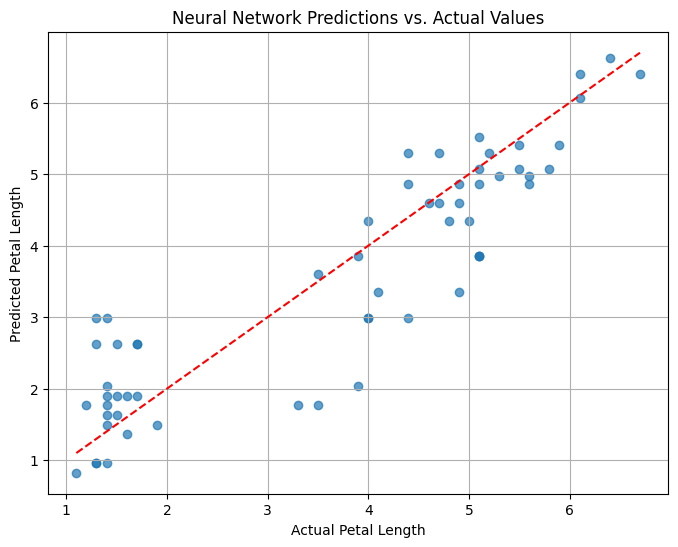

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.xlabel("Actual Petal Length")
plt.ylabel("Predicted Petal Length")
plt.title("Neural Network Predictions vs. Actual Values")
plt.grid(True)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Diagonal line for perfect prediction
plt.show()